In [2]:
## Standard libraries ====
import os
import random
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

## Visualization ====
import logomaker
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

## PyTorch and Machine learning ====
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split

## Utilities ====
from util import getPFM, Motif2Seqs, sci_ticks

In [3]:
## Set random seed for reproducibility
def set_seed(seed):
    """Set seed for reproducibility across libraries."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    # If using GPUs:
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # For deterministic operations (optional, can slow things down):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## Set seed
SEED = 777
set_seed(SEED)

## Determine if a GPU is available and select the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

## TensorBoard setup instructions (can be uncommented in a notebook)
%load_ext tensorboard
%tensorboard --logdir=runs --port=5678

Using device: cuda


Reusing TensorBoard on port 5678 (pid 42380), started 0:07:30 ago. (Use '!kill 42380' to kill it.)

In [4]:
def stratified_sample(df, col, counts, seed=SEED):
    """
    Performs stratified sampling by extracting a specified number of samples from each bin of a column in the dataframe.
    The column is divided into bins, and a defined number of samples is taken from each bin.

    Args:
        df (pd.DataFrame): The input dataframe.
        col (str): The column used for creating bins, which serves as the basis for stratification.
        counts (list): Number of samples to extract from each bin, corresponding to each created bin.
        seed (int): Random seed for reproducibility.

    Returns:
        pd.DataFrame: Dataframe containing the extracted stratified samples.
    """
    np.random.seed(seed)
    df['grp'] = pd.cut(df[col], bins=len(counts))
    extracted = pd.concat(
        df[df['grp'] == grp].sample(cnt, replace=True, random_state=seed)
        for grp, cnt in zip(sorted(df['grp'].unique()), counts)
        )
    return extracted.drop(columns=['grp'])

In [5]:
def dna_one_hot(seq, flatten=False):
    """
    Convert a DNA sequence to its one-hot encoded binary representation.

    Parameters:
        seq (str): The DNA sequence to convert, consisting of characters 'A', 'C', 'G', 'T', or '-'.
        flatten (bool): Whether to return the array in a flattened form (default is False).
    
    Returns:
        np.ndarray: A numpy array of one-hot encoded binary arrays representing the DNA sequence.
                    Each base is represented by a binary array of length 4, where only one element is 1 (indicating the base) and all others are 0.
                    The character '-' is represented by an array of all zeros. If flatten is True, the array will be flattened to a 1D array.
    """
    mapping = {'A': [1, 0, 0, 0], 'C': [0, 1, 0, 0], 'G': [0, 0, 1, 0], 'T': [0, 0, 0, 1], '-': [0, 0, 0, 0], 'N': [1/4, 1/4, 1/4, 1/4]}
    one_hot = np.array([mapping.get(base, [0, 0, 0, 0]) for base in seq.upper()]).T
    return one_hot.flatten() if flatten else one_hot

In [6]:
df_UL = pd.read_pickle("../tables/UL.pkl")
df_UL = df_UL[(df_UL['LogGFP']>1) & (df_UL['LogGFP']<4)]
df_UL = stratified_sample(df_UL, 'LogGFP', [500, 1000, 1500, 1500, 1000, 500])[['rep1', 'rep2', 'LogGFP']]
df_UL['Sequence'] = df_UL.index
df_UL['Library'] = "UL"

df_train = pd.concat([df_UL]).reset_index(drop=True)
df_train

,rep1,rep2,LogGFP,Sequence,Library
0,1.189172,1.461953,1.325562,ATGGCTAAAGACCTTTGTC,UL
1,0.960728,1.237040,1.098884,TAAACCTTGGCGAATCAAT,UL
2,1.419035,1.246626,1.332831,GAATCGCAGACTTTGTCCT,UL
3,1.880356,0.763662,1.322009,TTATTTCGAATGTATCAAT,UL
4,1.367954,1.033681,1.200817,ATTTTTAAGCATGATCAAT,UL
...,...,...,...,...,...
5995,2.965819,3.031932,2.998876,ACTCGATCTTGGTAATTAA,UL
5996,2.965819,3.031932,2.998876,ACTCGATCTTGGTAATTAA,UL
5997,2.504497,3.045250,2.774873,CCAAAACAGATGGGATTTA,UL
5998,2.694453,3.044327,2.869390,CTTTATAGGTGTAATTTAG,UL


In [7]:
df_UL = pd.read_pickle("../tables/UL.pkl")
df_UL

,rep1,rep2,count1,count2,LogGFP
CAAATTCTGACCGTTCTCA,1.907493,2.239796,24.0,37.0,2.073645
CATAGAGCGTCTGTTCTCA,1.979857,2.156400,48.0,22.0,2.068129
CAAACCTCACCTTATGTAT,1.853220,2.251052,21.0,13.0,2.052136
CACGAACGATACGGTAATT,1.907493,1.806818,16.0,15.0,1.857156
GTACGTGTGAAGTGCCAAT,1.809065,1.784607,59.0,25.0,1.796836
...,...,...,...,...,...
ACCATCCAATTCAATGCCT,1.717982,1.652378,61.0,16.0,1.685180
GACAGAATGACACATGAAC,1.928730,2.251052,23.0,19.0,2.089891
CATTGAACTAGCTGATCTA,1.904300,2.207214,17.0,19.0,2.055757
TCTAAGCATATTCGAACCA,1.923628,1.510662,37.0,18.0,1.717145


In [8]:
df_UL.to_csv("../UP_library.tsv", sep='\t')

In [9]:
class DNAFunctionPredictor(nn.Module):
    def __init__(self, seq_length, num_conds):
        super(DNAFunctionPredictor, self).__init__()
        self.seq_length = seq_length
        
        ## Conv1D layer for DNA sequence
        self.conv1 = nn.Conv1d(in_channels=4, out_channels=1, kernel_size=19, stride=1)
        self._initialize_conv1()
        
        # self.conv2 = nn.Conv1d(in_channels=2, out_channels=3, kernel_size=25, stride=1) # 31+2+1
        # self._initialize_conv2()
        
        ## Define custom trainable parameters for self-defined function
        self.param_max = nn.Parameter(torch.tensor(np.log(1000)), requires_grad=True)
        self.param_min = nn.Parameter(torch.tensor(np.log(0.5)), requires_grad=True)
        self.param_e0 = nn.Parameter(torch.tensor(0.0), requires_grad=True)
        
        ## Fully connected layers
        self.fc1 = nn.Linear(num_conds + 1, 8)  # Adjust input size
        self.fc2 = nn.Linear(8, 8)
        self.fc3 = nn.Linear(8, 1)  # Output a single value

    def _initialize_conv1(self):
        # ## Define custom motifs for each filter
        # motif1 = getPFM(Motif2Seqs("TTGACA"), ratios=True).values.T  # Shape: (4, 6)
        # motif2 = getPFM(Motif2Seqs("TATAAT"), ratios=True).values.T  # Shape: (4, 6)
    
        # ## Combine into a single array for one filter
        # filter1_weights = np.concatenate([np.zeros((4, 8)), motif1, np.zeros((4, 8))], axis=1)
        # filter2_weights = np.concatenate([np.zeros((4, 8)), motif2, np.zeros((4, 8))], axis=1)
    
        # ## Stack filters to form the weight tensor (out_channels, in_channels, kernel_size)
        # custom_weights = np.stack([filter1_weights, filter2_weights], axis=0)
    
        ## Assign the custom weights to the layer
        self.conv1.weight.data.zero_()
        self.conv1.weight.requires_grad = True
    
        ## Set the biases to zero
        self.conv1.bias.data.zero_()
        self.conv1.bias.requires_grad = False

    # def _initialize_conv2(self):    
    #     ## Define the weights directly using numpy
    #     filter1_weights = np.zeros((2, 25))
    #     filter2_weights = np.zeros((2, 25))
    #     filter3_weights = np.zeros((2, 25))
        
    #     filter1_weights[0, 0], filter1_weights[1, 24] = 1, 1
    #     filter2_weights[0, 1], filter2_weights[1, 24] = 1, 1
    #     filter3_weights[0, 2], filter3_weights[1, 24] = 1, 1
    
    #     ## Stack filters to form the weight tensor (out_channels, in_channels, kernel_size)
    #     custom_weights = np.stack([filter1_weights, filter2_weights, filter3_weights], axis=0)
    
    #     ## Assign the custom weights to the layer
    #     self.conv2.weight.data = torch.tensor(custom_weights, dtype=torch.float32)
    #     self.conv2.weight.requires_grad = False
    
    #     ## Set the biases to zero
    #     self.conv2.bias.data.zero_()
    #     self.conv2.bias.requires_grad = True
    
    def energy(self, dna_seq):
        """
        Process the DNA sequence through Conv1D and apply global max pooling.
        :param dna_seq: DNA sequence (batch_size, 4, seq_length)
        :return: Processed sequence features (batch_size, 1)
        """
        x = self.conv1(dna_seq)
        # x = self.conv2(x)
        x = x.view(x.size(0), -1)  # Remove the channel dimension
        x = F.max_pool1d(x, kernel_size=x.size(-1))  # Global max pooling
        return x

    def energy2expression(self, x):
        """
        Custom function with Boltzmann weight and logarithmic transformation.
        :param x: Input tensor (batch_size, num_features)
        :return: Transformed tensor based on the custom formula.
        """
        ## Calculate Boltzmann weight
        beta = 1/(0.001987*310) # 1/(kB*T) ~ 1.6234
        BoltzWeight = torch.exp(beta * (x + self.param_e0))
        
        ## Exponentiate trainable parameters for Max and Min
        Max = torch.exp(self.param_max)
        Min = torch.exp(self.param_min)
        
        ## Custom expression
        expression = torch.log(Min + Max * (BoltzWeight) / (1+BoltzWeight))
        
        return expression

    def forward(self, dna_seq, conds):
        """
        Forward pass for the model.
        :param dna_seq: DNA sequence (batch_size, 4, seq_length)
        :param conds: One-hot encoded experimental conditions (batch_size, num_conds)
        """
        ## Process the DNA sequence
        x = self.energy(dna_seq)  # (batch_size, 1)
        
        ## Pass through the self-defined function
        output = self.energy2expression(x)
        
        return output

## Training ====

In [10]:
## Data Preparation
## =======================
## Convert DNA sequences to one-hot encoding and prepare conditions
dna_seq = np.array(list(df_train['Sequence'].apply(dna_one_hot)))  # (batch_size, 4, seq_length)
dan_func = df_train['LogGFP'].values * np.log(10)  # Target values for regression
conds = np.vstack([
    # np.repeat([[1, 0, 0, 0, 0, 0]], 10000, axis=0),
    # np.repeat([[0, 1, 0, 0, 0, 0]], 3000, axis=0),
    # np.repeat([[0, 0, 1, 0, 0, 0]], 4000, axis=0),
    # np.repeat([[0, 0, 0, 1, 0, 0]], 3000, axis=0),
    # np.repeat([[0, 0, 0, 0, 1, 0]], 2000, axis=0),
    np.repeat([[0, 0, 0, 0, 0, 1]], 6000, axis=0),
    ])

## Split data into training and testing sets
TEST_SIZE = 0.2
X_train_seq, X_test_seq, X_train_conds, X_test_conds, y_train, y_test = train_test_split(
    dna_seq, conds, dan_func, test_size=TEST_SIZE, random_state=42
    )

## Convert data to PyTorch tensors and move to device
X_train_seq = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
X_train_conds = torch.tensor(X_train_conds, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

X_test_seq = torch.tensor(X_test_seq, dtype=torch.float32).to(device)
X_test_conds = torch.tensor(X_test_conds, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

## Create DataLoaders for batching
BATCH_SIZE = 32
train_dataset = TensorDataset(X_train_seq, X_train_conds, y_train)
test_dataset = TensorDataset(X_test_seq, X_test_conds, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
# Model Initialization
# =======================
seq_length = dna_seq.shape[2]  # Sequence length
num_conds = conds.shape[1]  # Number of experimental conditions

model = DNAFunctionPredictor(seq_length=seq_length, num_conds=num_conds).to(device)

# Optimizer and Loss Function
# =======================
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # L2 regularization

# TensorBoard Setup
# =======================
TENSORBOARD_LOG_DIR = "runs/20250628_UP_v0"
writer = SummaryWriter(TENSORBOARD_LOG_DIR)

# Training Loop
# =======================
EPOCHS = 30
for epoch in range(EPOCHS):
    # Training Phase
    model.train()
    for seq_batch, cond_batch, target_batch in train_loader:
        # Move batches to device
        seq_batch, cond_batch, target_batch = seq_batch.to(device), cond_batch.to(device), target_batch.to(device)
        
        # Forward pass and optimization
        optimizer.zero_grad()
        output = model(seq_batch, cond_batch)
        loss = criterion(output, target_batch)
        loss.backward()
        optimizer.step()

    # Evaluation Phase
    model.eval()
    with torch.no_grad():
        # Evaluate on training set
        train_loss = criterion(model(X_train_seq, X_train_conds)/np.log(10), y_train/np.log(10))
        # Evaluate on testing set
        test_loss = criterion(model(X_test_seq, X_test_conds)/np.log(10), y_test/np.log(10))

    # Log results
    print(f"Epoch [{(epoch+1):02d}/{EPOCHS}] - Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}")
    writer.add_scalars('Loss', {'Training Loss': train_loss.item(), 'Testing Loss': test_loss.item()}, epoch+1)

# Close TensorBoard Writer
writer.close()

Epoch [01/30] - Train Loss: 0.1393, Test Loss: 0.1472
Epoch [02/30] - Train Loss: 0.0978, Test Loss: 0.1006
Epoch [03/30] - Train Loss: 0.0837, Test Loss: 0.0833
Epoch [04/30] - Train Loss: 0.0792, Test Loss: 0.0777
Epoch [05/30] - Train Loss: 0.0778, Test Loss: 0.0754
Epoch [06/30] - Train Loss: 0.0772, Test Loss: 0.0745
Epoch [07/30] - Train Loss: 0.0770, Test Loss: 0.0745
Epoch [08/30] - Train Loss: 0.0769, Test Loss: 0.0742
Epoch [09/30] - Train Loss: 0.0770, Test Loss: 0.0737
Epoch [10/30] - Train Loss: 0.0768, Test Loss: 0.0738
Epoch [11/30] - Train Loss: 0.0767, Test Loss: 0.0738
Epoch [12/30] - Train Loss: 0.0768, Test Loss: 0.0739
Epoch [13/30] - Train Loss: 0.0767, Test Loss: 0.0738
Epoch [14/30] - Train Loss: 0.0768, Test Loss: 0.0737
Epoch [15/30] - Train Loss: 0.0767, Test Loss: 0.0738
Epoch [16/30] - Train Loss: 0.0767, Test Loss: 0.0736
Epoch [17/30] - Train Loss: 0.0766, Test Loss: 0.0735
Epoch [18/30] - Train Loss: 0.0765, Test Loss: 0.0736
Epoch [19/30] - Train Loss: 

In [12]:
# === 產出元件並寫入共用 CSV（自給自足；放 stop 之前讓 run-all 可達）===
ELEM_NAME = "UP";  DATA_PKL = "../tables/UL.pkl"   # UP element（19bp）

SHARED_CSV = "../tables/elements_shared.csv"

def _write_column(csv_path, coldata):
    base = pd.read_csv(csv_path) if os.path.exists(csv_path) else pd.DataFrame()
    new = pd.DataFrame(coldata)
    n = max(len(base), len(new))
    base = base.reindex(range(n)); new = new.reindex(range(n))
    for c in new.columns: base[c] = new[c]
    base.to_csv(csv_path, index=False); return base

def _energy(seqs):
    X = torch.tensor(np.array([dna_one_hot(s) for s in seqs]), dtype=torch.float32).to(device)
    with torch.no_grad(): return model.energy(X).cpu().squeeze(1).numpy()
def _correction():
    W = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[0]).T, columns=['A','C','G','T'])
    return W.mean(axis=1).sum()

_df = pd.read_pickle(DATA_PKL).copy()
_df['Energy'] = _energy(list(_df.index)) - _correction()
_df = _df.reset_index(); _df.columns = ['Sequence'] + list(_df.columns[1:])
_df = _df.sort_values('Energy', ascending=False).reset_index(drop=True)

N = len(_df); _t = [(i + 0.5) / 5 for i in range(5)]
_picks = _df.iloc[[int(round(t * (N - 1))) for t in _t]].reset_index(drop=True)
_write_column(SHARED_CSV, {f'{ELEM_NAME}_seq': _picks['Sequence'].tolist(),
                           f'{ELEM_NAME}_pct': [round((1 - t) * 100) for t in _t]})
print(f"✅ 已寫入 {ELEM_NAME} → {SHARED_CSV}"); _picks[['Sequence', 'Energy']]


PermissionError: [Errno 13] Permission denied: '../tables/elements_shared.csv'

## Show Conv1d Layer ====

In [ ]:
def ShowLogo(ax, pwm):    
    ## custom color scheme
    color_scheme = {
        'A' : 'green',
        'C' : 'blue',
        'G' : 'orange',
        'T' : 'red',
        u'АСᏀТ': '#dfdfdf'
        }

    ## plot the Logo
    pwm_logo = logomaker.Logo(pwm,
                              shade_below=.6,
                              fade_below=.6,
                              font_name='DejaVu Sans',
                              color_scheme=color_scheme,
                              ax=ax)
    
    return None

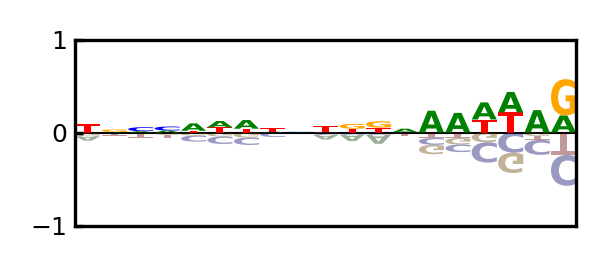

In [ ]:
df_logo = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[0]).T, columns=['A', 'C', 'G', 'T'])
df_logo = df_logo.sub(df_logo.mean(axis=1), axis=0)  # Center each row

fig, ax = plt.subplots(figsize=(2.2, 1), dpi=300, sharey=True)

ShowLogo(ax, df_logo)
ax.set_xticks([])
# ax.set_yticks([-.3, 0, .3])
ax.set_ylim(-1, 1)
ax.tick_params(axis='both', which='both', labelsize=6, direction='in', length=2, pad=2)

plt.tight_layout()
# plt.savefig("../figures/Logo_UL.svg")
plt.show()

In [ ]:
stop

NameError: name 'stop' is not defined

In [ ]:
def getEnergies(seqs):
    seqs_arr = np.array([dna_one_hot(seq) for seq in seqs])
    seqs_arr_tensor = torch.tensor(seqs_arr, dtype=torch.float32).to(device)    
    energies = model.energy(seqs_arr_tensor).cpu().squeeze(1).detach().numpy()
    return energies

def predict(seqs):
    seqs_arr = np.array([dna_one_hot(seq) for seq in seqs])
    seqs_arr_tensor = torch.tensor(seqs_arr, dtype=torch.float32).to(device)    
    expressions = model.energy2expression(model.energy(seqs_arr_tensor)).cpu().squeeze(1).detach().numpy()
    return expressions/np.log(10)

def correctionTerm():
    df_weight = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[0]).T, columns=['A', 'C', 'G', 'T'])
    return df_weight.mean(axis=1).sum()

In [ ]:
df = pd.read_pickle("../tables/UL.pkl")
df = df[(df['LogGFP']>1) & (df['LogGFP']<4)]
df['Energy'] = getEnergies(df.index) - correctionTerm()
df['LogGFP_pred'] = predict(df.index)
df

,rep1,rep2,count1,count2,LogGFP,Energy,LogGFP_pred
CAAATTCTGACCGTTCTCA,1.907493,2.239796,24.0,37.0,2.073645,-0.135460,1.905747
CATAGAGCGTCTGTTCTCA,1.979857,2.156400,48.0,22.0,2.068129,-0.110379,1.921855
CAAACCTCACCTTATGTAT,1.853220,2.251052,21.0,13.0,2.052136,0.139609,2.080175
CACGAACGATACGGTAATT,1.907493,1.806818,16.0,15.0,1.857156,0.022738,2.006726
GTACGTGTGAAGTGCCAAT,1.809065,1.784607,59.0,25.0,1.796836,-0.258632,1.826213
...,...,...,...,...,...,...,...
ACCATCCAATTCAATGCCT,1.717982,1.652378,61.0,16.0,1.685180,-0.549393,1.636808
GACAGAATGACACATGAAC,1.928730,2.251052,23.0,19.0,2.089891,0.235291,2.139388
CATTGAACTAGCTGATCTA,1.904300,2.207214,17.0,19.0,2.055757,0.103785,2.057782
TCTAAGCATATTCGAACCA,1.923628,1.510662,37.0,18.0,1.717145,0.149505,2.086341


In [ ]:
xs = np.linspace(-8, 4, 101)
xs_tensor = torch.tensor((xs + correctionTerm())[:, np.newaxis], dtype=torch.float32).to(device)
ys = model.energy2expression(xs_tensor).cpu().detach().numpy().flatten()/np.log(10)

In [ ]:
np.mean(np.abs(df['LogGFP'] - df['LogGFP_pred']))  # MAE

0.14625802542376035

In [ ]:
# 1. 讀全部 DL 序列並算能量 + 模型預測
df = pd.read_pickle("../tables/UL.pkl").copy()
df['Energy']      = getEnergies(df.index) - correctionTerm()
df['LogGFP_pred'] = predict(df.index)

# 2. 用 Energy 由強到弱排序
metric = 'Energy'   # 想改用實測就換成 'LogGFP'
df_sorted = df.sort_values(metric, ascending=False)
df_sorted.index.name = 'Sequence'
df_sorted = df_sorted.reset_index()
n = len(df_sorted)

# 3. 取 5 個區間中心 (強→弱)：rank 10/30/50/70/90 %
#    若想要 B 方案(ㄇ100/75/50/25/0%)，改成 [0.0, 0.25, 0.5, 0.75, 1.0]
targets = [0.1, 0.3, 0.5, 0.7, 0.9]
picks = [df_sorted.iloc[int(round(t*(n-1)))] for t in targets]

df_picks = pd.DataFrame(picks).reset_index(drop=True)
df_picks['Strength_level'] = ['~90% (最強)', '~70%', '~50%', '~30%', '~12.5% (最弱)']
df_picks[['Strength_level', 'Sequence', 'LogGFP', 'LogGFP_pred', 'Energy']]


,Strength_level,Sequence,LogGFP,LogGFP_pred,Energy
0,~90% (最強),CTTTGTTATAGTAACTGTG,1.936160,2.276608,0.463898
1,~70%,ATGACATACACCCTGTTCA,2.030722,2.095867,0.164825
2,~50%,AATCATGCAGGGTACGTTC,1.971603,1.969076,-0.036534
3,~30%,AGCTATCATATGGGTTGAC,1.948278,1.842993,-0.232725
4,~12.5% (最弱),TACCCTAACCTAATCGGTT,1.644350,1.658582,-0.516043


In [ ]:
def score_sequences(seqs):
    """輸入 17bp spacer 序列，回傳能量、預測 GFP；若序列在資料庫中，附上實測 LogGFP。"""
    if isinstance(seqs, str):
        seqs = [seqs]

    # 模型推算
    df_out = pd.DataFrame({'Sequence': seqs})
    df_out['Energy']      = getEnergies(seqs) - correctionTerm()
    df_out['LogGFP_pred'] = predict(seqs)
    df_out['GFP_pred']    = 10 ** df_out['LogGFP_pred']

    # 查資料庫實測值（不在庫的會是 NaN）
    df_db = pd.read_pickle("../tables/UL.pkl")
    df_out['LogGFP_meas'] = df_out['Sequence'].map(df_db['LogGFP'])
    df_out['in_database'] = df_out['LogGFP_meas'].notna()

    return df_out[['Sequence', 'in_database', 'LogGFP_meas', 'LogGFP_pred', 'GFP_pred', 'Energy']]

# === 使用範例 ===
score_sequences(["CTTTGTTATAGTAACTGTG", "AGCTATCATATGGGTTGAC","AATCATGCAGGGTACGTTC" ,"ATGACATACACCCTGTTCA", "CTTTGTTATAGTAACTGTG"])
# 多條：
# score_sequences(["ATGGGATATATGACCAG", "CCTTAGTAGGCGATATC"])


,Sequence,in_database,LogGFP_meas,LogGFP_pred,GFP_pred,Energy
0,CTTTGTTATAGTAACTGTG,True,1.936160,2.276608,189.063522,0.463898
1,AGCTATCATATGGGTTGAC,True,1.948278,1.842993,69.661552,-0.232725
2,AATCATGCAGGGTACGTTC,True,1.971603,1.969076,93.127167,-0.036534
3,ATGACATACACCCTGTTCA,True,2.030722,2.095867,124.700134,0.164825
4,CTTTGTTATAGTAACTGTG,True,1.936160,2.276608,189.063522,0.463898
